## Imports & Config

In [36]:
import importlib

import meta_information
import problem_instance
import solution_instance
import swap_2_player
import simulated_annealing
importlib.reload(meta_information)
importlib.reload(problem_instance)
importlib.reload(solution_instance)
importlib.reload(swap_2_player)
importlib.reload(simulated_annealing)

from meta_information import MetaInformationPlotter, MetaInformation
from problem_instance import ProblemInstance
from solution_instance import SolutionInstance
from swap_2_player import Swap2Player
from simulated_annealing import SimulatedAnnealing

# Social Golfer Problem Config
NUM_GROUPS = 3
NUM_PLAYERS = 10
NUM_WEEKS = 4

# Simulated Annealing Config
INIT_TEMP = 1000
FINAL_TEMP = 0.01
EQI_ITER = 20
ALPHA = 0.90

## Run Simulated Annealing

Violation Count: 7
Week 0:
  Group 0: [2, 3, 0]
  Group 1: [7, 6, 1]
  Group 2: [4, 5, 8]
Week 1:
  Group 0: [0, 2, 5]
  Group 1: [3, 8, 1]
  Group 2: [7, 6, 4]
Week 2:
  Group 0: [6, 8, 2]
  Group 1: [4, 7, 0]
  Group 2: [5, 1, 9]
Week 3:
  Group 0: [3, 0, 1]
  Group 1: [7, 9, 8]
  Group 2: [4, 6, 2]

Move Infos: 
Delta: 2
WeekA: 1 WeekB: 0
GroupA: 1 GroupB: 2
PlayerIDXA: 0 PlayerIDXB: 1
Iteration 0: Accepted move with delta=2, violations=7
Move Infos: 
Delta: -2
WeekA: 1 WeekB: 1
GroupA: 2 GroupB: 0
PlayerIDXA: 1 PlayerIDXB: 2
Iteration 1: Accepted move with delta=-2, violations=5
Move Infos: 
Delta: 3
WeekA: 0 WeekB: 0
GroupA: 1 GroupB: 2
PlayerIDXA: 1 PlayerIDXB: 1
Iteration 2: Accepted move with delta=3, violations=8
Move Infos: 
Delta: -1
WeekA: 3 WeekB: 0
GroupA: 2 GroupB: 1
PlayerIDXA: 0 PlayerIDXB: 0
Iteration 3: Accepted move with delta=-1, violations=7
Move Infos: 
Delta: 0
WeekA: 0 WeekB: 0
GroupA: 0 GroupB: 1
PlayerIDXA: 1 PlayerIDXB: 0
Iteration 4: Accepted move with delt

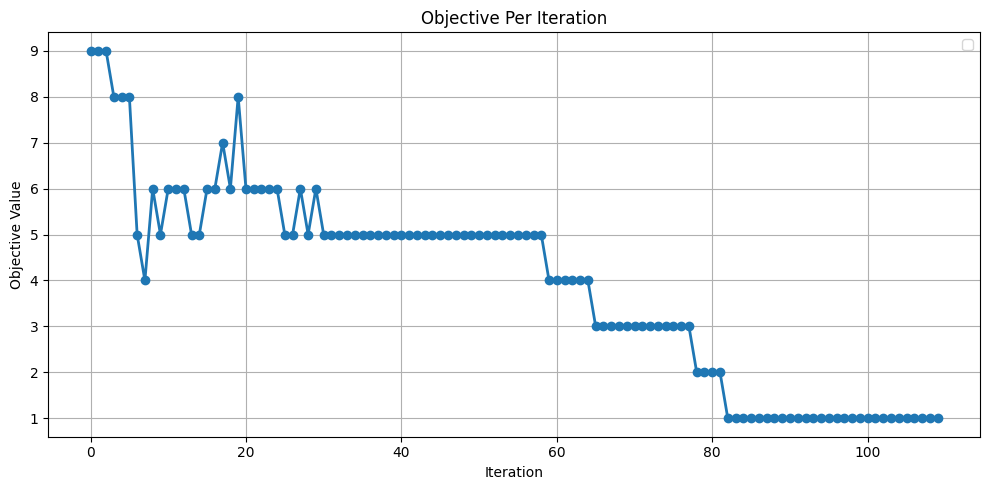

In [37]:
problem_instance = ProblemInstance(NUM_GROUPS,NUM_PLAYERS,NUM_WEEKS)
neighborhood = Swap2Player()
solution_instance = SolutionInstance(problem_instance, SolutionInstance.generate_random_solution, neighborhood)
print(solution_instance)
sa_solver = SimulatedAnnealing(
    solution_instance,
    init_temperature=INIT_TEMP,
    final_temperature=FINAL_TEMP,
    equilibrium_iterations=EQI_ITER,
    alpha=ALPHA)


meta_infos = []
best_solution = sa_solver.solve()
print(f"Best solution found with {best_solution.count_violations()} violations: \n{best_solution}")
meta_infos.append(sa_solver.meta_inf)

MetaInformationPlotter.plot_meta_info(meta_infos=meta_infos)